In [ ]:
!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
#https://drive.google.com/file/d/1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2/view?usp=sharing

Downloading...
From: https://drive.google.com/uc?id=1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2
To: /content/multiclass.csv
100% 14.6k/14.6k [00:00<00:00, 42.9MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('multiclass.csv')

df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


In [ ]:
df.shape

(440, 8)

In [ ]:
df = pd.get_dummies(df, columns = ['Region'])

#storing class label
Y = df['class']
df = pd.get_dummies(df, columns = ['class'])

df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region_1,Region_2,Region_3,class_1,class_2,class_3
0,12669,9656,7561,214,2674,1338,0,0,1,0,1,0
1,7057,9810,9568,1762,3293,1776,0,0,1,0,1,0
2,6353,8808,7684,2405,3516,7844,0,0,1,0,1,0
3,13265,1196,4221,6404,507,1788,0,0,1,1,0,0
4,22615,5410,7198,3915,1777,5185,0,0,1,1,0,0


In [ ]:
X = df.drop(columns=['class_1','class_2','class_3'])
y = df[['class_1','class_2','class_3']]

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

print('Train : ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test  : ', X_test.shape, y_test.shape)

Train :  (356, 9) (356, 3)
Validation: (40, 9) (40, 3)
Test  :  (44, 9) (44, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


# For Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
def create_baseline():

  model = Sequential([
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(128, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(64, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(32, activation="relu",kernel_initializer='glorot_uniform'),
                    Dense(3,activation='softmax')])
  return model

In [ ]:
model = create_baseline()

ValueError: ignored

In [ ]:
model.compile(optimizer = tf.keras.optimizers.SGD(),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=10, batch_size=128)


Epoch 1/10
3/3 [==============================] - 2s 153ms/step - loss: 1.1147 - val_loss: 1.1187
Epoch 2/10
3/3 [==============================] - 0s 14ms/step - loss: 1.1023 - val_loss: 1.1047
Epoch 3/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0911 - val_loss: 1.0917
Epoch 4/10
3/3 [==============================] - 0s 13ms/step - loss: 1.0810 - val_loss: 1.0801
Epoch 5/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0722 - val_loss: 1.0707
Epoch 6/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0648 - val_loss: 1.0623
Epoch 7/10
3/3 [==============================] - 0s 15ms/step - loss: 1.0581 - val_loss: 1.0545
Epoch 8/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0520 - val_loss: 1.0476
Epoch 9/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0463 - val_loss: 1.0410
Epoch 10/10
3/3 [==============================] - 0s 14ms/step - loss: 1.0410 - val_loss: 1.0347


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                320       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 64)                8256      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 3)                 99        
                                                                 
Total params: 21,187
Trainable params: 21,187
Non-traina

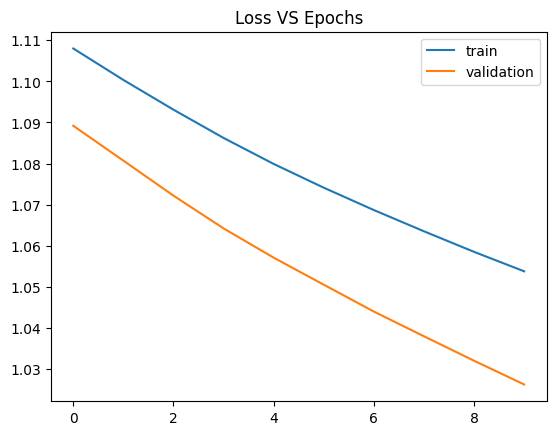

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



In [ ]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=200, batch_size=128)


Epoch 1/200
3/3 [==============================] - 1s 99ms/step - loss: 1.1290 - val_loss: 1.1269
Epoch 2/200
3/3 [==============================] - 0s 17ms/step - loss: 1.1182 - val_loss: 1.1144
Epoch 3/200
3/3 [==============================] - 0s 18ms/step - loss: 1.1078 - val_loss: 1.1019
Epoch 4/200
3/3 [==============================] - 0s 17ms/step - loss: 1.0979 - val_loss: 1.0900
Epoch 5/200
3/3 [==============================] - 0s 19ms/step - loss: 1.0887 - val_loss: 1.0793
Epoch 6/200
3/3 [==============================] - 0s 19ms/step - loss: 1.0802 - val_loss: 1.0689
Epoch 7/200
3/3 [==============================] - 0s 17ms/step - loss: 1.0721 - val_loss: 1.0584
Epoch 8/200
3/3 [==============================] - 0s 20ms/step - loss: 1.0643 - val_loss: 1.0486
Epoch 9/200
3/3 [==============================] - 0s 17ms/step - loss: 1.0568 - val_loss: 1.0391
Epoch 10/200
3/3 [==============================] - 0s 18ms/step - loss: 1.0496 - val_loss: 1.0302
Epoch 11/200
3/3 [=

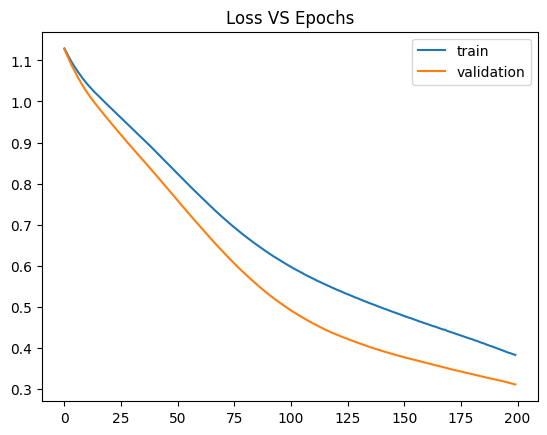

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()

In [ ]:
model_gdm = create_baseline()

In [ ]:
model_gdm.compile(optimizer = tf.keras.optimizers.SGD(momentum=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history = model_gdm.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)


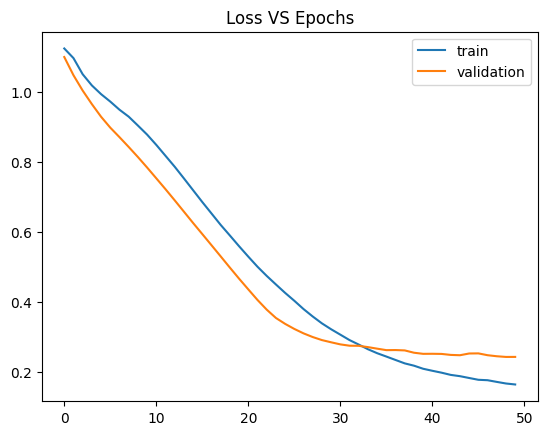

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



In [ ]:
model_rms = create_baseline()

In [ ]:
model_rms.compile(optimizer = tf.keras.optimizers.RMSprop(rho=0.9),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history = model_rms.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)


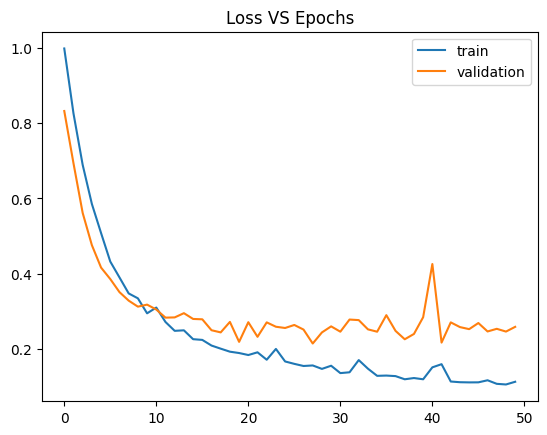

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



In [ ]:
model_adam = create_baseline()
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1=0.9, beta_2=0.999),
                loss = tf.keras.losses.CategoricalCrossentropy() )

In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50, batch_size=128, verbose = 0)


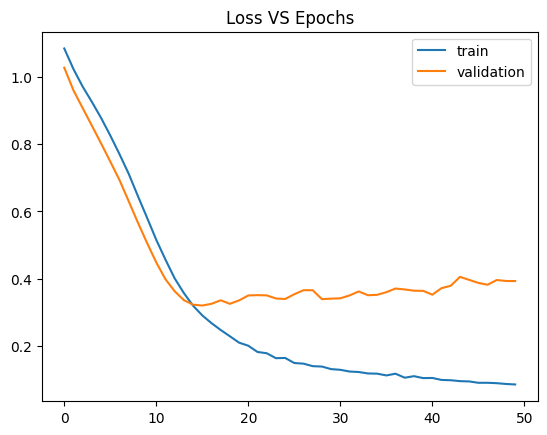

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



In [ ]:
loss

[1.0850837230682373,
 1.0237122774124146,
 0.9715498089790344,
 0.926078736782074,
 0.8783749938011169,
 0.826033353805542,
 0.7705872058868408,
 0.7121574878692627,
 0.6458685398101807,
 0.581120491027832,
 0.5153455138206482,
 0.4564402401447296,
 0.4006519913673401,
 0.3569514751434326,
 0.3192709684371948,
 0.29051345586776733,
 0.2674787640571594,
 0.24710988998413086,
 0.22838640213012695,
 0.20937377214431763,
 0.20022021234035492,
 0.18166856467723846,
 0.17788662016391754,
 0.16320867836475372,
 0.16388437151908875,
 0.1488107293844223,
 0.1468668133020401,
 0.1394524872303009,
 0.13826479017734528,
 0.1306268572807312,
 0.1286141723394394,
 0.12344785034656525,
 0.12205657362937927,
 0.11772695928812027,
 0.11712250113487244,
 0.11185723543167114,
 0.11695600301027298,
 0.10506539046764374,
 0.10965640097856522,
 0.10387156903743744,
 0.10432036221027374,
 0.09840977191925049,
 0.0975511446595192,
 0.0948379784822464,
 0.09400419145822525,
 0.08990436792373657,
 0.08997147530

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

In [ ]:
def scheduler(epoch, lr):
  r_0 = 0.01
  lr = (1/(1+r_0*epoch))*lr

  return lr

In [ ]:
LRdecay = LearningRateScheduler(scheduler)

In [ ]:
model_adam = create_baseline()

In [ ]:
model_adam.compile(optimizer = tf.keras.optimizers.Adam(beta_1 = 0.9, beta_2 = 0.999 ),
                loss = tf.keras.losses.CategoricalCrossentropy() )


In [ ]:
history = model_adam.fit(X_train, y_train, validation_data = (X_val, y_val),  epochs=50,
                         batch_size=128,callbacks=[LRdecay], verbose = 0)


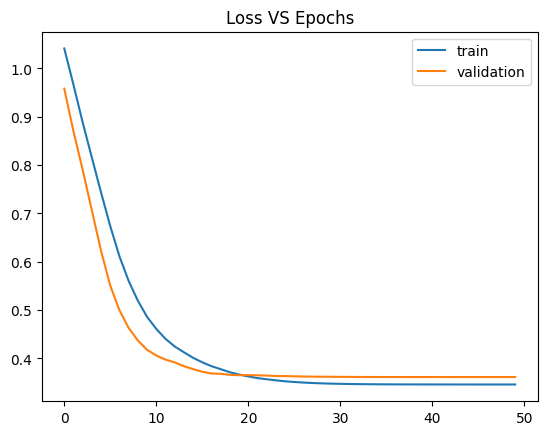

In [ ]:
epochs = history.epoch
loss = history.history["loss"]
val_loss = history.history["val_loss"]


plt.plot(epochs, loss, label="train")
plt.plot(epochs, val_loss, label="validation")

plt.legend()
plt.title("Loss VS Epochs")

plt.show()



In neural networks, an initializer (also referred to as weight initialization) is a technique used to set the initial values 
of the weights and biases of the network's neurons. Proper weight initialization can have a significant impact on the training process and the final performance of the neural network. The choice of initializer can influence factors like the convergence speed, gradient behavior, and overall training stability. Here are some common weight initializers used in neural networks:


## Zero Initialization:
Initializing all weights and biases to zero is not recommended. It can lead to symmetry breaking issues where all neurons in a layer learn the same features, effectively making the neural network behave like a single neuron.

## Random Initialization:
Random initialization involves assigning random values to the weights and biases. This breaks symmetry and helps each neuron to learn different features. Common random initialization methods include:

### Uniform Initialization: 
Random values are drawn from a uniform distribution.
###  Normal (Gaussian) Initialization:
Random values are drawn from a Gaussian distribution with mean 0 and a specified standard deviation.

## Xavier/Glorot Initialization:
Xavier (also known as Glorot) initialization is designed to balance the scale of gradients during backpropagation. It's particularly effective for sigmoid and hyperbolic tangent (tanh) activation functions. The weights are initialized with random values drawn from a distribution with mean 0 and variance scaled based on the number of input and output neurons in the layer.

## He Initialization:
He initialization is similar to Xavier initialization but is optimized for ReLU (Rectified Linear Unit) activation functions and their variants. It uses a scaling factor based on the number of input neurons only.

## LeCun Initialization:
This initialization is designed for activation functions like Leaky ReLU. It's similar to He initialization but considers the slope of the leaky part of the Leaky ReLU activation function.

## Orthogonal Initialization:
This method initializes weights as orthogonal matrices. It can be helpful for recurrent neural networks (RNNs) where orthogonal matrices can help stabilize gradients during backpropagation.

## Pretrained Initialization:
Transfer learning involves using weights pre-trained on a similar task or dataset. These pretrained weights can be used to initialize the neural network for fine-tuning on a new task.

The choice of initializer depends on the specific architecture of the neural network, the activation functions used, and the nature of the problem. Incorrect initialization can lead to vanishing or exploding gradients, which can hinder training. Experimenting with different initializers and monitoring their effects on the training process can help improve the performance of your neural network.




